In [122]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [123]:
from handcalcs import *
from handcalcs import render
import handcalcs

In [124]:
def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]


In [125]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

In [126]:
# CONFIGURATIONS
#help(handcalcs.set_option)
handcalcs.set_option("latex_block_start", "$")
handcalcs.set_option("latex_block_end", "$")
handcalcs.set_option("math_environment_end", "aligned")
handcalcs.set_option("use_scientific_notation",True)

In [127]:
from figModel import *

# Flyback 400V/12V design

<br><br><br><br><br>
<img src = "figs/Schematic_fly.png">

## Table of contents

## Introduction

### Inputs 

In [128]:
%%render 
Vin_nom=380 # v
Vin_max = 400 # v
Vin_min = 360 # v
Vout_nom=12 # v
Power_out= 3.4 # w
delta_Vout = 0.01 # 1 percent

<IPython.core.display.Latex object>

### Simplified overall schematic

In [129]:

fig_counter=One_figure_with_captions(fig_counter, img1="schema1.png"
                                     , caption1="Simplified overall schematic",
                                     first_part_path="Schematic/", 
                                     width=19)

### The PWM controller

#### Introduction of the TNY2XX familly

We will use a **TNY2xx family** controller  

**Why:**  
* This controller has an **integrated MOSFET**  
* It requires a **minimum BOM**  
* It can operate **without an auxiliary winding**
* It provides integrated frequency jitter (**spread spectrum** to reduce EMI perturbation)

**How this controller works ():**  
* This controller works with **max-current / max-duty-cycle**  
* It has an **internal clock** that fixes the maximum switching frequency  
  * example: **132 kHz**  
* In each cycle, it checks the **feedback pin**  
  * if the feedback pin is activated → **skip (escape) the cycle**  
  * otherwise → **turn on the MOSFET**  
* The MOSFET turns off when **one of the following conditions is met:**  
  * the **primary current** reaches the maximum value  
    * example: **250 mA**  
  * or the **duty cycle** reaches the maximum allowed value  
    * example: **62%**

* This controller has an **internal 5.8 V generator**  
  * used for **self-powering**  
  * no external auxiliary supply is required

For more information pease check the datasheet below [\[1\]](#referencesID8488445fd1).

<br><br>
In this design, we will shose the **TNY-264** in open frame configuration
* Breakdown Voltage = 700
* Power = 9W
* Frequancy = 132kHz with +/-8kHz of jitter
* Rds(ON) = 28Ω @ 25°C and 42Ω @ 100°C (typ), 48Ω in the worst case
* Ilim = 250mA (typ)
* Max duty cycle = 65% (typ)

<br><br>
Let’s estimate the theorical maximum power that this controller can extract

In [130]:
%%render 
I_lim = 0.250 # A
Freq = 132e3# Hz 
Freq_max = 140e3 # Hz
DC_max = 0.65 
Vin_max = 400 # V
di = I_lim-0 # A


<IPython.core.display.Latex object>

In [131]:
%%render 3 sci_not long

dt =DC_max * (1/ Freq) # s
L = Vin_max / (di/dt)# H because v = L di/dt
L_uH = L*1e6 # µH
E_cycle = 1e6 * 1/2 *L*I_lim**2 # µJ

<IPython.core.display.Latex object>

In [132]:
%%render  long
P_inp= Freq * E_cycle *1e-6  # W
Efficiency = 0.8 # hypothesis
P_out = P_inp*Efficiency # W > 9W of the datasheet

<IPython.core.display.Latex object>

Let's estimate the thermal discipation in this condition (only conduction losses)

In [133]:
%%render  long
Rds_max = 48
Erds_cycle=(1/3)* Rds_max *I_lim**2 *dt*1e6 # uJ (current is a slope from 0 to I lim)
Prds=Freq * Erds_cycle *1e-6  # W
Rth_JA= 45 # °C/W see the datasheet
Delta_T=Rth_JA*Prds # °C

<IPython.core.display.Latex object>

* The ΔT in this condition is relatively low, because in this quick calculation we assume that the only loss inside the IC is the ohmic loss caused by RDS_ON
* In reality, there are additional losses, such as switching losses (especially at 132 kHz) and the internal power consumption of the controller.

In our design, the maximum output power will be 4 W, so we respect the datasheet.

#### Simulation for Understanding TNY‑264, TNY‑280 ...
To clearly understand how this controller works, I suggest the following step-by-step simulation, beginning with the simplest configuration and gradually introducing more advanced features. The goal is to improve conceptual understanding, not to provide a fully rigorous or exact model of the controller.

You can find all these simplified models in the [link](https://github.com/BOAB235/Design_of_1200W_LLC_DCDC/tree/main/03_hw_design/01_design_justification/07_power_supp/01_FlyBack/TNY264_Models).

**Level 1 :**

At this level, the PWM controller model includes only a master frequency clock (set to 132.45 kHz in the example below) and a current‑limit reset. 
<BR>Even with this simplified model, the controller is able to perform primary peak‑current control. 

See the purple current curve in the simulation shown below.

In [134]:
fig_counter=One_figure_with_captions(fig_counter, img1="MODEL1.png"
                                     , caption1="TNY2xx modeling: Level 1, reset triggered by the max-current.",
                                     first_part_path="TNY264_Models/", 
                                     width=19)

**Level 2 :**
 
At this stage, the maximum duty‑cycle reset control is added. The controller resets whenever one of the following conditions occurs:

*   The current reaches its maximum target value.
*   The duty cycle exceeds the controller’s maximum allowed value (approximately 63%).

In the first figure below, the reset is always triggered by the maximum current.
<br>For the second figure, the reset is triggered by the maximum duty cycle.


In [135]:
fig_counter=One_figure_with_captions(fig_counter, img1="MODEL2_1.png"
                                     , caption1="TNY2xx modeling: Level 2, reset triggered by the max-current.",
                                     first_part_path="TNY264_Models/", 
                                     width=19)

In [136]:
fig_counter=One_figure_with_captions(fig_counter, img1="MODEL2_2.png"
                                     , caption1="TNY2xx modeling: Level 2, reset triggered by the max-duty cycle.",
                                     first_part_path="TNY264_Models/", 
                                     width=19)

**Level 3 :**
 
At this level, we introduce the feedback control. The feedback is evaluated at the start of each cycle, and if it is active, the current cycle is skipped. This results in fewer cycles, reduced current, and lower voltage until the feedback is deactivated, after which normal operation resumes.

In [137]:
fig_counter=One_figure_with_captions(fig_counter, img1="MODEL3.png"
                                     , caption1="2D drawing of core TDK ELP 22/6/16 with I 22/2.5/16 N87",
                                     first_part_path="TNY264_Models/", 
                                     width=19)

## The transformer design

let's start with this TDK planner small core 
**ELP 22/6/16 with I 22/2.5/16 N87**


In [138]:
fig_counter=One_figure_with_captions(fig_counter, img1="core.png"
                                     , caption1="2D drawing of core TDK ELP 22/6/16 with I 22/2.5/16 N87",
                                     first_part_path="figs/", 
                                     width=12)

In [139]:
%%render 
Bs = 0.3            # Saturation Flux Density (T)
Ae_mm2 = 78.5       # Effective Cross Section Area (mm2)
le_mm = 26.1    # Magnetic Path Length (mm)
ui = 1360           # Initial Permeability (N87 material)
AL = 5200 # nH :type

<IPython.core.display.Latex object>

For more information pease check the datasheet below [\[1\]](#referencesID8488445fd1).

In [140]:
%%render 3 sci_not long
mu_0 = 4 * np.pi * 1e-7 # Permeability of Free Space
Ae = Ae_mm2 * 1e-6 # m2
le = le_mm= 26.1e-3 #m

<IPython.core.display.Latex object>

<u>**One example calculation**</u>

**For a generic flyback converter**, the calculation is like this:

In [141]:
%%render params 
Vd = 0.4        # Diode Forward Drop in V
Np=50
Ns=10

<IPython.core.display.Latex object>

In [142]:
%%render 3 sci_not long







n = Np / Ns
Vrefl = n * (Vout_nom + Vd)
D = Vrefl / (Vin_max + Vrefl)



Ton = D  / Freq

# 2. Correct Bpeak calculation (No division by 2 for Flyback)
Bpeak = (Vin_max * Ton) / (Np * Ae)

# 3. Magnetizing Inductance (Lm)
Lm = AL * (Np**2) * 1e-9 # convert nH to Henrys

# 4. Peak Currents
Ippeak = (Vin_max * Ton) / Lm
Is_peak = Ippeak * n

# 5. Air Gap Calculation (lg)
# Formula: lg = (mu_0 * Np^2 * Ae / Lm) - (le / ui)
#lg = ((mu_0 * (Np**2) * Ae) / Lm) - (le / ui)

# 6. Output Power (DCM assumption)
Effec = 0.8
Ps = 0.5 * Lm * (Ippeak**2) * Freq * Effec

Margin = (Bs - Bpeak) / Bs

flux = Bs*Ae

lamb= flux *Np

I_sat = lamb *Np/Lm # please keep in mind the margin




<IPython.core.display.Latex object>

But for our **max-current max-duty-cycle TNY-264** the calculation is below

**In first time let's focus on the primary side**

* Initial time step:  
  $dt = DC_{\text{max}} \cdot \dfrac{1}{\text{Freq}}$

* Calculate maximum DC current:  
  $I_{\text{dcmax}} = \dfrac{V_{\text{in\_nom}} \cdot dt}{L_m}$

* Conditional calculation:  

  * If $I_{\text{dcmax}} < I_{\text{lim}}$:  
    $I_{\text{peak}} = I_{\text{dcmax}}$<br>
    $D = DC_{\text{max}}$


  * Else:  
    $I_{\text{peak}} = I_{\text{lim}}$  
    $dt = \dfrac{L_m \cdot I_{\text{lim}}}{V_{\text{in\_nom}}}$
 
    $D = \dfrac{dt}{ Freq}$


In [143]:
%%render 3 sci_not
Lm = AL * (Np**2) * 1e-9 # H
dt =DC_max * (1/ Freq) # s
I_dcmax= Vin_nom*dt/Lm # v = L di/dt
Ipeak = I_dcmax # since Idcmax < Ilim

<IPython.core.display.Latex object>

In [144]:
%%render 
Bpeak = Vin_nom*dt/(Np*Ae) # > Bsat = 0.3 Wb
Margin = (Bs - Bpeak) / Bs # NOK

<IPython.core.display.Latex object>

The primary stored power

In [145]:
%%render 
Power_prim = Freq*(1/2)*Lm*Ipeak**2 # W

<IPython.core.display.Latex object>

Below a table of some Np value and corresponding Bpeak, Margin, Duty cycle (D), ...

In [146]:
arr = []

for Np in range(10, 101, 10):  # Primary turns
    #for Ns in range(4, 9,2):     # Secondary turns
    if 1: 
        Lm = AL * (Np**2) * 1e-9 # H
        dt =DC_max * (1/ Freq) # s
        I_dcmax= Vin_nom*dt/Lm # v = L di/dt
        if I_dcmax < I_lim:
            Ipeak = I_dcmax # since Idcmax < Ilim
            D = DC_max
        else: 
            Ipeak = I_lim
            dt = Lm*I_lim/Vin_nom
            D = dt*Freq
        Bpeak = Vin_nom*dt/(Np*Ae) # 
        Margin = (Bs - Bpeak) / Bs # 
        Power_prim = Freq*(1/2)*Lm*Ipeak**2 # W
        #if Margin >= 0.15: # Only keep designs with 15% flux margin
        if 1:
            arr.append({
                "Np": Np, 
                #"Ns": Ns, 
                "D": round(D, 3), 
                "Ipeak":Ipeak , 
                 
                "Lm_uH": round(Lm*1e6, 1),
                #"Ip_peak": round(Ippeak, 2), "Ps_W": round(Ps, 1),
                #"Gap_mm": round(lg * 1000, 3) , # convert to mm
                
                #"I_sat": I_sat
                "Power_prim":Power_prim, 
                "Bpeak": round(Bpeak, 3),
                "Margin %": 100*Margin, 
            })

df = pd.DataFrame(arr)#.sort_values('Bpeak')

#m =df.Margin>0
#df= df[m]
#print(df.to_string(index=False))
#from IPython.display import display
#display(df.style.hide(axis="index"))
df

,Np,D,Ipeak,Lm_uH,Power_prim,Bpeak,Margin %
0,10,0.045,0.250000,520.0,2.145000,0.166,44.798301
1,20,0.181,0.250000,2080.0,8.580000,0.331,-10.403397
2,30,0.406,0.250000,4680.0,19.305000,0.497,-65.605096
3,40,0.650,0.224905,8320.0,27.775805,0.596,-98.642476
4,50,0.650,0.143939,13000.0,17.776515,0.477,-58.913981
5,60,0.650,0.099958,18720.0,12.344802,0.397,-32.428317
6,70,0.650,0.073438,25480.0,9.069651,0.341,-13.509986
7,80,0.650,0.056226,33280.0,6.943951,0.298,0.678762
8,90,0.650,0.044426,42120.0,5.486579,0.265,11.714455
9,100,0.650,0.035985,52000.0,4.444129,0.238,20.543010


Filter with dutyCycle > 10%

In [147]:
df[df.D>0.1]

,Np,D,Ipeak,Lm_uH,Power_prim,Bpeak,Margin %
1,20,0.181,0.250000,2080.0,8.580000,0.331,-10.403397
2,30,0.406,0.250000,4680.0,19.305000,0.497,-65.605096
3,40,0.650,0.224905,8320.0,27.775805,0.596,-98.642476
4,50,0.650,0.143939,13000.0,17.776515,0.477,-58.913981
5,60,0.650,0.099958,18720.0,12.344802,0.397,-32.428317
6,70,0.650,0.073438,25480.0,9.069651,0.341,-13.509986
7,80,0.650,0.056226,33280.0,6.943951,0.298,0.678762
8,90,0.650,0.044426,42120.0,5.486579,0.265,11.714455
9,100,0.650,0.035985,52000.0,4.444129,0.238,20.543010


So we can see that it’s difficult to meet our requirement without adding an air gap and while keeping Np reasonable, so let’s try adding an air gap.

Below is the calculation of the air gap using the TDK formula.

In [148]:
%%render 
#Lm_uH = 2000 # uH : a chosen value
#Np = 25 # example 
#AL= Lm_uH*1e3/Np**2 # nH
AL = 2400 # nH : a chosen value
K1=134 # see the core datasheet
K2 = -0.806 # see the core datasheet
air_gap = (AL/K1)**(1/K2) # AL in nH and gap in mm

<IPython.core.display.Latex object>

For airgap calculation, see [\[4\]](#referencesID12326dfnjdd2).

In [149]:
#For airgap calculation, see [\[2\]](#referencesID8488445fd2).

In [150]:
arr = []

for Np in range(16, 31, 2):  # Primary turns
    #for Ns in range(4, 9,2):     # Secondary turns
    if 1: 
        #AL= Lm_uH*1e3/Np**2 # nH
        Lm = AL * (Np**2) * 1e-9 # H
        dt =DC_max * (1/ Freq) # s
        I_dcmax= Vin_nom*dt/Lm # v = L di/dt
        if I_dcmax < I_lim:
            Ipeak = I_dcmax # since Idcmax < Ilim
            D = DC_max
        else: 
            Ipeak = I_lim
            dt = Lm*I_lim/Vin_nom
            D = dt*Freq
        Bpeak = Vin_nom*dt/(Np*Ae) # 
        Margin = (Bs - Bpeak) / Bs # 
        Power_prim = Freq*(1/2)*Lm*Ipeak**2 # W
        #if Margin >= 0.15: # Only keep designs with 15% flux margin
        if 1:
            arr.append({
                "Np": Np, 
                #"Ns": Ns, 
                "D": round(D, 3), 
                "Ipeak":Ipeak , 
                 
                "Lm_uH": round(Lm*1e6, 1),
                #"Ip_peak": round(Ippeak, 2), "Ps_W": round(Ps, 1),
                #"Gap_mm": round(lg * 1000, 3) , # convert to mm
                
                #"I_sat": I_sat
                "Power_prim":Power_prim, 
                "Bpeak": round(Bpeak, 3),
                "Margin %": 100*Margin, 
            })

df = pd.DataFrame(arr)#.sort_values('Bpeak')

#m =df.Margin>0
#df= df[m]
#print(df.to_string(index=False))
#from IPython.display import display
#display(df.style.hide(axis="index"))
df

,Np,D,Ipeak,Lm_uH,Power_prim,Bpeak,Margin %
0,16,0.053,0.25,614.4,2.5344,0.122,59.235669
1,18,0.068,0.25,777.6,3.2076,0.138,54.140127
2,20,0.083,0.25,960.0,3.9600,0.153,49.044586
3,22,0.101,0.25,1161.6,4.7916,0.168,43.949045
4,24,0.120,0.25,1382.4,5.7024,0.183,38.853503
5,26,0.141,0.25,1622.4,6.6924,0.199,33.757962
6,28,0.163,0.25,1881.6,7.7616,0.214,28.662420
7,30,0.188,0.25,2160.0,8.9100,0.229,23.566879


Let's start with Np = 26 turns; it's a good compromise between primary power and Bpeak.
<br><br>**Let's chose an Ns**
<br>
To avoid saturation of the core, the magnetic flux ($B$) must return to 0 in each cycle. This means that the magnetizing inductance must discharge completely into the secondary before the end of the cycle. Therefore, the final magnetizing current must be 0A.

In [151]:
D = df[df.Np==26]["D"].values[0]
Ipeak  = df[df.Np==26]["Ipeak"].values[0]
Lm_uH  = df[df.Np==26]["Lm_uH"].values[0]

Below an example with Ns = 2


* $D:$ The duty cycle corresponding to $T_{on}$ on the primary mosfet
* $ D_{secondary}$ : The duty cycle corresponding to $T_{on}$ on the secondary diode
* $ D_{conduction}$ : The sum of the above duty cycles must be less than one

In [152]:
%%render 
Np= 26
Ns = 2 # example 
n= Np/Ns
D = D  # see above table for Np = 26
Ipeak = Ipeak # A see above table for Np = 26
Lm_uH = Lm_uH#  uH see above table for Np = 26
#dt_us = 1e6*(1-D)/Freq # us
Isec_peak = n*Ipeak
dIsec = Isec_peak-0
Vo = Vout_nom + Vd # V


<IPython.core.display.Latex object>

In [153]:
%%render long

Lms_uH = Lm_uH  /n**2 # uH secondary magnetic inductance

dtSec_us = Lms_uH * dIsec / Vo # us reminder v=Ldi/dt
D_secondary =dtSec_us * 1e-6 *Freq 


<IPython.core.display.Latex object>

In [154]:
%%render long


D_conduction = D + D_secondary   # must be < 1 
Vrefl= (Vout_nom+Vd)*n # V : This voltage stresses the primary MOSFET

<IPython.core.display.Latex object>

Let's repeat the same calculation for different Ns:

In [155]:
arr = []
for Ns in range(2,9):
    n= Np/Ns
    #D = 0.188 # see above table for Np = 26
    #Ipeak = 250e-3 # A see above table for Np = 26
    #Lm_uH = 2163.2#  uH see above table for Np = 26
    #dt_us = 1e6*(1-D)/Freq # us
    Isec_peak = n*Ipeak
    dIsec = Isec_peak-0
    Lms_uH = Lm_uH  /n**2 # uH secondary magnetic inductance
    Vo = (Vout_nom+Vd) # V
    dtSec_us = Lms_uH * dIsec / Vo # us reminder v=Ldi/dt
    D_secondary =dtSec_us * 1e-6 *Freq 
    D_conduction = D + D_secondary   # must be < 1 
    Vrefl= (Vout_nom+Vd)*n # V
    dic = {
        "Ns":Ns,
        "Isec_peak": Isec_peak, 
        "Lms_uH": Lms_uH, 
        "dtSec_us": dtSec_us, 
        "D_secondary": D_secondary, 
        "D_conduction": D_conduction, 
        "Vrefl": Vrefl}
    arr.append(dic)
        
pd.DataFrame(arr)      


,Ns,Isec_peak,Lms_uH,dtSec_us,D_secondary,D_conduction,Vrefl
0,2,3.250000,9.6,2.516129,0.332129,0.473129,161.200000
1,3,2.166667,21.6,3.774194,0.498194,0.639194,107.466667
2,4,1.625000,38.4,5.032258,0.664258,0.805258,80.600000
3,5,1.300000,60.0,6.290323,0.830323,0.971323,64.480000
4,6,1.083333,86.4,7.548387,0.996387,1.137387,53.733333
5,7,0.928571,117.6,8.806452,1.162452,1.303452,46.057143
6,8,0.812500,153.6,10.064516,1.328516,1.469516,40.300000


The idea is to pick the highest Ns that ensures the secondary cycle discharges completely, in order to minimize the secondary peak current.

With **Ns = 4**, the full discharge of the magnetic tank is ensured: a good compromise between the $D\_{conduction}$ condition and $V\_{refl}$.



So we will start with **Np = 26 and Ns= 4 and an AL = 2400 nH that provide Lm = 1622 uH in primary side**

## RCD snubber

For details of formulas, please check the document [\[3\]](#referencesID8488445fd3).

Refer to the schematic above to see the snubber position.

In [156]:
%%render 3 sci_not long
Lm_uH = 1622
Leakage = 0.03 # Hypothesis 
Llk1_uH = Lm_uH*Leakage # uH

<IPython.core.display.Latex object>

In [157]:
%%render 3 sci_not long
Lm= Lm_uH*1e-6
Llk1 =Llk1_uH *1e-6
Np = 26
Ns = 4
V_breakDown = 700 # see Tny-264 datasheet
V_maxRating = 0.8*V_breakDown # 20 percent of margin 


<IPython.core.display.Latex object>

The snubber allowed voltage is  

In [158]:
%%render 
Vsn = V_maxRating-Vin_max  # V

<IPython.core.display.Latex object>

**Chose the snubber resistor Rsn**

In [159]:
%%render long
Vrefl= (Vout_nom+Vd)*n # V
FacV= Vsn/(Vsn-Vrefl)
Rsn= Vsn**2/(0.5*Llk1*Ipeak**2*Freq*FacV) # Ω

<IPython.core.display.Latex object>

Let's chose Rsn = 82 kΩ
<br> with this value the Vsn will be 

In [160]:
from math import *

In [161]:
%%render long
Rsn = 82e3 # Ω
Vsn = (Vrefl + sqrt(Vrefl**2 + 2*Llk1*Ipeak**2*Freq*Rsn)) / 2 # V

<IPython.core.display.Latex object>

The power of Rsn is

In [162]:
%%render 
P_Rsn = Vsn**2/Rsn # W

<IPython.core.display.Latex object>

Let's choose **Rsn = 82kΩ / 2W** to avoid any under-designing.

* To define the snubber capacitor, let's start ith allowed ripple of **5Vpp**

In [163]:
%%render 
Fmin=( 132-8 ) * 1e3 # kHz

<IPython.core.display.Latex object>

In [164]:
%%render 
Delta_Vsn = 5
Csn_nF = 1e9*Vsn /(Delta_Vsn  *Rsn * Fmin) # nF
Csn= 1e-9*Csn_nF # F
Delta_Vsn_percent = 100*Delta_Vsn / Vsn # percent

<IPython.core.display.Latex object>

Let's chose a **Cns = 10nF**
<br>With this value the ripple will be:

In [165]:
%%render 3 sci_not
Csn =10e-9  # F

<IPython.core.display.Latex object>

In [166]:
%%render
Delta_Vsn = Vsn /(Csn *Rsn * Fmin) # V
Delta_Vsn_percent = 100*Delta_Vsn / Vsn # percent

<IPython.core.display.Latex object>

The current of this capacitor will be 

In [167]:
%%render
Z_csn= 1/(2*pi*Csn*Freq) # Ω
I_Csn= Delta_Vsn/Z_csn # App
I_CsnRms= I_Csn/(2*sqrt(2)) # Arms
I_CsnRms_mA= I_CsnRms*1e3 # mArms

<IPython.core.display.Latex object>

So the **Csn = 10nF** with minimum current of **5mA(rms)**

## The output capacitor

### Hypothesis of a sinusoidal current in the capacitor.

This hypothesis is not valid in our case, because the secondary current waveform in the transformer is a triangle that starts at its maximum value and decreases to zero, with no current during the charging phase. However, we will calculate the capacitor using this hypothesis just for information and comparison.

In [168]:
%%render  params
Freq # Hz
Vout_nom # v
Power_out # w
delta_Vout=0.01 # 1 \%
D # duty cycle

<IPython.core.display.Latex object>

Calculate the output capacitor for a target of 1% output voltage ripple.

In [169]:
%%render 
I_out= Power_out/Vout_nom # A
Delta_Vout = delta_Vout*Vout_nom # V
C_out_uF= 1e6*I_out/(Delta_Vout*Freq) # uF


<IPython.core.display.Latex object>

In [170]:
%%render 3 sci_not
C_out=C_out_uF*1e-6 # F

<IPython.core.display.Latex object>

In [171]:
%%render 
Z_Cout = 1/(C_out*2*pi*Freq)  # Ω
I_Cout =Delta_Vout /Z_Cout # App
I_Cout_RMS =I_Cout/(2*sqrt(2)) # Arms

<IPython.core.display.Latex object>

### Output capacitor of the flyback using the real waveforms

Input data for the calculation

In [172]:
%%render params 3 sci_not
Lm=1622*1e-6 # H
Np = 26
Ns = 4
delta_Vout =0.01 # 1 \%
Vout_nom # v
Vd = 0.4        # Diode Forward Drop in V



<IPython.core.display.Latex object>

In [173]:
%%render 
Delta_Vout = delta_Vout*Vout_nom # V
n = Np/Ns

<IPython.core.display.Latex object>

In [174]:
%%render 
Vo =  Vout_nom + Vd # V

<IPython.core.display.Latex object>

In [175]:
%%render 
Ipeak = 0.25 # A, Primary fixed by the controller limit

<IPython.core.display.Latex object>

Calculate the secondary inductance and ON time

In [176]:
%%render 3 sci_not long
Lms = Lm  /n**2 # secondary magnetic inductance, H
Is_peak = n*Ipeak # A , secondary
dIsec= Is_peak - 0
dtSec = Lms * dIsec / Vo # in seconds , reminder v=Ldi/dt

<IPython.core.display.Latex object>

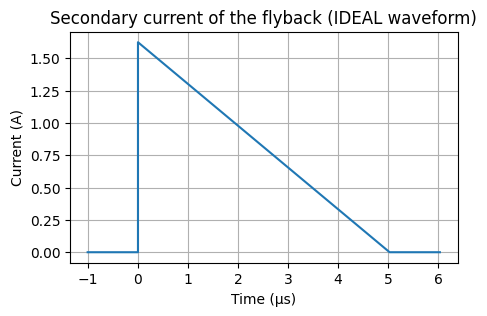

In [177]:
plt.subplots(figsize=(5, 3))
plt.plot(1e6*np.array([-dtSec*0.2,0,0,dtSec, dtSec*1.2 ]), [0,0,Ipeak*n,0,0])
plt.title("Secondary current of the flyback (IDEAL waveform)")
plt.xlabel("Time (µs)")
plt.ylabel("Current (A)")
plt.grid()
plt.show()

Current in the capacitor

$i = C \dfrac{dv_{out}}{dt}$

The secondary current decreases linearly from $I_0$ to $0$ during $dt_{sec}$, where $I_0 = n \cdot I_{peak}$ is the secondary peak current:

$i(t) = I_0\left(1-\dfrac{t}{dt_{sec}}\right)$

Voltage variation on the capacitor:

$\Delta V_{out} = \dfrac{1}{C}\int_0^{dt_{sec}} i(t)\,dt$

$\Delta V_{out} = \dfrac{1}{C}\int_0^{dt_{sec}} I_0\left(1-\dfrac{t}{dt_{sec}}\right) dt$

$\Delta V_{out} = \dfrac{1}{C}\left[I_0 t - \dfrac{I_0}{2dt_{sec}}t^2\right]_0^{dt_{sec}}$

$\Delta V_{out} = \dfrac{1}{C}\left(I_0 dt_{sec} - \dfrac{I_0}{2}dt_{sec}\right)$

$\Delta V_{out} = \dfrac{I_0\,dt_{sec}}{2C}$

Using $dt_{sec} = \dfrac{L_{ms}\,\Delta I_{sec}}{V_o}$ 

where $V_o = V_{out} + V_d$ is the voltage across the transformer secondary (including the diode drop), and $\Delta I_{sec} = I_0$:

$\Delta V_{out} = \dfrac{I_0^2 \, L_{ms}}{2C\,V_o}$

Since $L_{ms} = \dfrac{L_m}{n^2}$ and $I_0 = n \cdot I_{peak}$:

$\Delta V_{out} = \dfrac{n^2 \, I_{peak}^2 \cdot \dfrac{L_m}{n^2}}{2C\,V_o} = \dfrac{L_m \, I_{peak}^2}{2C\,V_o}$

And

$C = \dfrac{L_m \, I_{peak}^2}{2 \, V_o \, \Delta V_{out}}$

where $V_o = V_{out} + V_d$

In [178]:
%%render  3 sci_not
#Delta_V = delta_Vout*Vout_nom # V
C_out = Lm*Ipeak**2 / (2*Vo*Delta_Vout)


<IPython.core.display.Latex object>

In [179]:
%%render 
Co_uF = C_out*1e6 # uF

<IPython.core.display.Latex object>

For the current in the capacitor, we assume that the output current has no AC components, so all the AC ripple flows into the capacitor. Therefore, the capacitor’s peak current is equal to the peak current delivered by the secondary winding.

In [180]:
%%render 
Ic_peak =  Is_peak  # A

<IPython.core.display.Latex object>


Using the RMS definition to compute the $Is_{\text{rms}}$.


$Is_{rms} = \sqrt{\frac{1}{T}\int_0^{T} Is(t)^2 dt} $

$Is_{rms} = \sqrt{\frac{1}{T}\int_0^{dt_{sec}} Is_{peak}^2 \left(1 - \frac{t}{dt_{sec}}\right)^2 dt} = Is_{peak}\sqrt{\frac{dt_{sec}}{3T}}$

So in our case

In [181]:
%%render 3 sci_not
# RMS of triangular pulse: Is(t) = Is_peak*(1 - t/dtSec), from 0 to dtSec, zero elsewhere
# Is_rms = sqrt( (1/T) * integral_0^dtSec [ Is_peak^2 * (1 - t/dtSec)^2 ] dt )
#        = sqrt( Is_peak^2 * dtSec / (3*T) )
#        = Is_peak * sqrt( dtSec / (3*T) )
T_period = 1 / Freq  # s


<IPython.core.display.Latex object>

In [182]:
%%render 3 sci_not
Is_rms = Is_peak * sqrt(dtSec / (3 * T_period))  # A

<IPython.core.display.Latex object>

Below is a comparison between the simplified sinusoidal assumption and the more representative waveform of the flyback secondary.

In [183]:
pd.DataFrame([[17.89 , 34.064], 
[1.780,1.625],
[0.629, 0.7646]], columns = ["Sinusoidal", "Flyback Waveform"], index=["Min Co (µF)", "Capa Peak-Peak Current (App)", "Capa RMS current (Arms)"])

,Sinusoidal,Flyback Waveform
Min Co (µF),17.890,34.0640
Capa Peak-Peak Current (App),1.780,1.6250
Capa RMS current (Arms),0.629,0.7646


Verification: 

In [184]:
%%render 

Delta_Vout = Lm*Ipeak**2/(2*C_out*Vo)
delta_Vout =100*Delta_Vout/Vout_nom  # \% 

<IPython.core.display.Latex object>

Same value $\delta_{Vout}$ of our target

### The selected capacitor

We will use the capaitor **EEVFK1V471Q 470uF 35V 20%**

For more information pease check the datasheet below [\[1\]](#referencesID8488445fd1).

In [185]:
fig_counter=One_figure_with_captions(fig_counter, img1="Co.png"
                                     , caption1="Screenshot of the output capacitor" \
                                     " datasheet",
                                     first_part_path="figs/", 
                                     width=19)

**ESR estimation from $\tan(\delta)$**

The dissipation factor (loss tangent) of a capacitor is defined as: 

$\tan(\delta) = \dfrac{ESR}{X_C} = ESR \cdot \omega \cdot C = ESR \cdot 2\pi f \cdot C$

So:

$ESR = \dfrac{\tan(\delta)}{2\pi f \cdot C}$



In [186]:
%%render 3 sci_not
# Capacitor data
Co_nom_esr = 470e-6       # F, nominal capacitance
tol = 0.20                # 20\% tolerance
tan_delta = 0.12          # dissipation factor at 120 Hz, +20°C
f_tan = 120               # Hz, frequency of tan(delta) spec

# Worst case: minimum capacitance gives maximum ESR
C_min = Co_nom_esr * (1 - tol)  # F
ESR_max = tan_delta / (2 * pi * f_tan * C_min)  # Ohm

<IPython.core.display.Latex object>

Since we don't have ESR at heigh frequancy, we will use the simple ESR formula below: 

ESR frequency scaling for electrolytics [\[5\]](#referencesID12326dfndcjndcnjdfn2):
$ESR(f) = ESR(120Hz) \cdot \sqrt{\frac{120Hz}{f}}$

In [187]:
%%render 3 sci_not

ESR_switching = ESR_max * sqrt(120 / Fmin)  # ohm

<IPython.core.display.Latex object>

The power dissipation at the capacitor: 

In [188]:
%%render 3 sci_not
P_Co = Is_rms**2 * ESR_switching # W

<IPython.core.display.Latex object>

We don't have the thermal resistance of this capacitor, nor the maximum temperature associated with the maximum current. In the datasheet, we can see that the capacitor's Tmax is 105 °C, which corresponds to its maximum current. 

Let's assume that the temperature at the maximum current is 100 °C.
<br>So can estimate the $R_{th}$ as: 

In [189]:
%%render long
IrmsMax_datasheet = 1.1 # Arms from the datasheet @ 100 kHz / +105 °C
Tmax=105 # °C from the datasheet
T_maxI= 100 # °C, Hypothesis, max temperature at IrmsMax
P_maxI = IrmsMax_datasheet**2 * ESR_switching # W
R_th = (Tmax - T_maxI) / P_maxI  # °C/W

<IPython.core.display.Latex object>

For our operating point, the capacitor's T_max can be estimated using this relation.

In [190]:
%%render 
T_maxCo = P_Co * R_th + T_maxI # °C

<IPython.core.display.Latex object>

Let's estimate the **$\Delta_{Vout}$** in the worst case. We will assume that $\Delta_{Vout}$ is simply the sum of the maximum voltage caused by the capacitor and the maximum voltage caused by the ESR.

In [191]:
%%render 3 sci_not long
Delta_Vout_CAPA = Lm*Ipeak**2/(2*C_min*Vo) # V, Pure capacitor
Delta_Vout_ESR = Is_peak* ESR_switching  # V, Pure resistance
Delta_Vout_WORST= Delta_Vout_CAPA+Delta_Vout_ESR # V 

<IPython.core.display.Latex object>

Above is a simplified calculation but it is a maximum of what $\Delta_{Vout}$ can be.

Let’s check the relative voltage delta: 

In [192]:
%%render 
delta_Vout_WORST=Delta_Vout_WORST/Vout_nom*100 # \% < 1\% OK 

<IPython.core.display.Latex object>

## The final flyback Schematic & Modification

Below, you will find the original schematic followed by the updated version after the modifications.

#### Schematic

In [193]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="FlyBack_SchematicOld.png", 
                         caption1="The initial schematic of the flyback: 2 outputs to power the primary driver", 
                         first_part_path="./figs/", 
                         width=19)

In [194]:

fig_counter=One_figure_with_captions(fig_counter, 
                         img1="FlyBack_Schematic.png", 
                         caption1="The final flyback schematic with one output", 
                         first_part_path="./figs/", 
                         width=19)

#### Modifications

Below a table that resume all modifications in flyback circuit: 


| Change | Before | After | Why | Impact |
|------|--------|-------|-----|--------|
| IC controller | TNY280 | TNY264 | I_lim in TNY280 = 750 mA<br>vs 250 mA for TNY264<br>Risk of core saturation | Not< pin-to-pin equivalent<br>PCB modification |
| Output diode | MBRS340T3G | SB2100 | VRRM = 40 V (old)<br>vs 100 V (new)<br>VRRM of new design ≈ 62 V (peak) | Not SMD<br>PCB adaptation |
| Snubber diode | U51J | US2MA | VRRM = 600 V (old)<br>vs 1 kV (new)<br>More margin on VRRM | No PCB impact |
| Transformer air gap | No air gap | Add air gap | Avoid core saturation | Low cycle energy<br>(low power) |
| Transformer ratio | Np:Ns1:Ns2 = 8:1:1 | Np:Ns = 26:4 | Avoid core saturation | PCB impact<br>External winding needed<br>Primary winding: 8 turns on PCB <br>+ 18 turns with wire.|
| R13 (optocoupler parallel resistor) | Parallel with zener | Parallel with opto LED | Mistake in initial schematic | PCB impact |
| Zener | BZT52C11 | LLZ11 | Out of stock | Pin-to-pin compatible |
| BP capacitor C1 | 10 µF | 100 nF | Result of TNY280 → TNY264 | Pin-to-pin compatible |


#### PCB flyback zone

In [195]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Capture d’écran 2025-10-14 102005V2.png", 
                         caption1="Naked PCB: The PCB flyback zone", 
                         first_part_path="./figs/", 
                         width=12)

In [196]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="flybckpcb.png", 
                         caption1="The flyback with all modifications", 
                         first_part_path="./figs/", 
                         width=19)

As mensionned in the table above, the initial flyback is modified, so the final version is presented in the figure above (fast prototyping with manual modification of the PCB)

## Test & Measurements

### Setup

Below is the setup schematic displaying all the signal names used in this part.

In [197]:
fig_schematic=fig_counter
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="schema1_test2.png", 
                         caption1="TEST", 
                         first_part_path="./figs/", 
                         width=19)

### Small-signal transformer characterization

In this part, we will caracterize the transofrmer core using small signal only

In [198]:
fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="setup.png", 
                               caption1="Test Setup", 
                               img2="IMG_20251222_145518.jpg", 
                               caption2="The transformer winding", 
                               first_part_path="./figs/")

fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="IMG_20251221_152720.jpg", 
                               caption1="Photo of the setup", 
                               img2="2025-12-21_15-43-19-096.png", 
                               caption2="Oscilloscope ScreenShot", 
                               first_part_path="./figs/")

**Result analysis**

In this section, we will analyze the measured signals (Vp, Vs, Ip) as well as the estimated signals (Vs‑estimation and Ip‑estimation):

* The Vs‑estimation allows us to validate the transformer turns ratio Np/Ns
* The Ip‑estimation enables us to assess the inductance in small‑signal conditions

In [199]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="small_sig_trans.png", 
                         caption1="TEST", 
                         first_part_path="./figs/", 
                         width=19)

The results show that:

*   The estimated Vs aligns closely with the measured Vs (blue vs red), confirming that the turn ratio (Np, Ns) = (26, 4) is valid
*   The estimated Ip aligns closely the measured Ip (green vs black), suggesting that the primary inductance Lp is around 2000 µH

Below a simulation of this test using LT-Spice

In [200]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="small_sig_trans_sim.png",  
                         caption1="TEST", 
                         first_part_path="./figs/", 
                         width=14)



Below the calculation of the AL (nH/turns^2)

In [201]:
%%render long
Np= 26
Lp_uH = 2000 # uH
Lp_nH = Lp_uH*1e3 # nH
AL_nH= Lp_nH/Np**2 # nH/turns2
AL_nom = 5200 # nH/turns2 from the datasheet
diff = 100*(AL_nH-AL_nom)/AL_nom # \% > 25\% of the datasheet tolerance

<IPython.core.display.Latex object>

The difference between the measured values and the datasheet specifications can be attributed to the air gap present in our setup. 

To quantify this, we will estimate the equivalent air gap, assuming that the core's AL value matches the datasheet specification [\[1\]](#referencesID8488445fd1).


In [202]:
%%render 
#Lm_uH = 2000 # uH : a chosen value
#Np = 25 # example 
#AL= Lm_uH*1e3/Np**2 # nH
K1=134 # see the core datasheet
K2 = -0.806 # see the core datasheet
air_gap = (AL_nH/K1)**(1/K2) # mm

<IPython.core.display.Latex object>

Therefore, an effective air gap of 22 µm is reasonable, implying a physical gap of approximately 11 µm, as the magnetic flux passes through it twice, producing the 22 µm equivalent.


### Primary current and voltage 

**Setup**

In [203]:

fig_counter=One_figure_with_captions(fig_counter, 
                         img1="IMG_20251223_084143.png", 
                         caption1="Photo of the setup, we add a loop to measure the primary current", 
                         first_part_path="./figs/", 
                         width=19)

**Oscilloscope**

In [204]:

fig_counter=One_figure_with_captions(fig_counter, 
                         img1="2025-12-23_08-54-28-772.png", 
                         caption1="The measurement of Ip and Vp (oscilloscope shcreenshot)", 
                         first_part_path="./figs/", 
                         width=15)

In [205]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_345V_time.png", 
                         caption1="The measurement of Ip and Vp (oscilloscope data)", 
                         first_part_path="./figs/", 
                         width=19)

**Transformer chacarization**
<br>
In this preprocessing step, we isolate the ON phase of the primary MOSFET and estimate Lm and Rds:

*   Lm, the primary magnetizing inductance, is estimated from the slope of the current during the ON phase (v = L di/dt), as shown by the blue and black curves
*   Rds, the MOSFET's on‑resistance, is estimated from the voltage drop at the ON phase (v = Rds × I) using linear regression to reduce noise, as shown by the red and green curves.

In [206]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_345V_lm.png", 
                         caption1="Pre-Processing of the measurement: we extract the Lm and Rds_on from the Ip and Vp waveforms", 
                         first_part_path="./figs/", 
                         width=19)

From the above figure, the estimated Lm and Rds are: 

In [207]:

Lm= 1650 # uH 
Rds = [47.1,40.3,46.3]
Vin = [344.6,343.6,344.7]
Rds_avg = np.mean(Rds)
Vin_avg = np.mean(Vin)


The average Rds_on value is 44.5 Ω (see below), which falls within the datasheet specification range of [28 Ω, 48 Ω], see[\[1\]](#referencesID8488445fd1).

The average Vin is 344.3 V, and the measured value is about 345 V, which indicates good quality in the linear regression estimation.

In [208]:
%%render 
Lm # uH
Rds # Ω
Rds_avg # Ω
Vin # V
Vin_avg # V

<IPython.core.display.Latex object>

Let's estimate the AL and the airgap.

In [209]:
%%render 
Lp_nH = Lm*1e3 # nH
AL_nH= Lp_nH/Np**2 # nH/turns2

K1=134 # see the core datasheet
K2 = -0.806 # see the core datasheet
air_gap = (AL_nH/K1)**(1/K2) # mm

<IPython.core.display.Latex object>

So the above estimation suggests an air gap of 27 µm

**Estimation of the leakage inductance and the primary MOSFET capacitor**

In [210]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_345V_Llk_coss.png", 
                         caption1="Zoom on the Vp signal, slow/fast oscillation of Vp", 
                         first_part_path="./figs/", 
                         width=19)

<u>Coss estimation (left graph)</u>

In [211]:
%%render 3 sci_not
Lm = 1650 # uH see above estimation
t0=1.26e-05 # see left graph above, black instant 
t1= 2.05e-5 # see left graph above, black instant 
n=5 # Number of periods
fring= n/(t1-t0) # Ring frequency in Hz
Coss= 1/ ((2*pi)**2*Lm*1e-6*fring**2) # F



<IPython.core.display.Latex object>

Conventional units

In [212]:
%%render 
fring_MHz = fring*1e-6 # MHz
Coss_pF = Coss*1e12 # pF

<IPython.core.display.Latex object>

<u>Primary leakage inductance estimation (right graph)</u>

In [213]:
%%render 3 sci_not
t0=2.259e-5 # see right graph above, black instant 
t1= 2.325e-5 # see right graph above, black instant 
n=4 # Number of periods
fring= n/(t1-t0) # Ring frequency in Hz
Llk1 = 1/ ((2*pi)**2*Coss*fring**2) # H



<IPython.core.display.Latex object>

Conventional units

In [214]:
%%render 
fring_MHz = fring*1e-6 # MHz
Llk1_uH = Llk1*1e6 # uH
Prim_RelativeLeak = 100*Llk1_uH/Lm # \% relative leakage inductance

<IPython.core.display.Latex object>

So 1% of leakage in primary is normal value

### Verification of the max duty cycle 

For this test, we use the same setup as before, but we lower the input voltage to 48 V to force the TNY‑264 controller into its maximum duty‑cycle operation.

In [215]:

fig_counter=One_figure_with_captions(fig_counter, 
                         img1="2026-01-03_20-13-08-982.png", 
                         caption1="Oscilloscope screenshot", 
                         first_part_path="./figs/", 
                         width=15)

In [216]:

fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_48V_time3.png", 
                         caption1="Oscilloscope data at 47.5V input: Pre-Processing of the measurement", 
                         first_part_path="./figs/", 
                         width=19)

From the preprocessing of the measurements:

*   top-left graph: raw data, showing a primary peak current of roughly 125 mA, below the 250 mA limit—which confirms that the cycle is reset by reaching the maximum duty cycle
*   top-right graph: confirmation of the Np/Ns turns ratio
*   bottom-left: zoom on the Ton interval, used to compute Ton from t0 and t1 (see calculation below)
*   bottom-right: zoom showing two consecutive Ton intervals, used to estimate the switching frequency from t0 and t2 (see calculation below)


In [217]:
%%render 
t0=14.5 # µs 
t1=18.8 # µs
t2= 67.8 # µs
Ton = t1-t0 # µs
T = t2-t0 # µs

<IPython.core.display.Latex object>

The controller operates with a nominal frequency of 132 kHz, a ±6% tolerance, and an 8 kHz jitter. <br>Under low‑load conditions, however, it skips cycles, making the spacing between switching periods unpredictable. To handle this, we will iterate through the data to estimate the number of periods between two successive ON instants.

<br>Let's estimate the max-min frequencies using the tolerance and jitter: 

In [218]:
%%render long
Freq_cent_NOM=132  # kHz, nominal central frequency
Freq_min= Freq_cent_NOM*(1-0.06)-8 # kHz, min frequency, jitter and tolerance
Freq_max= Freq_cent_NOM*(1+0.06)+8 # kHz, max frequency, jitter and tolerance


<IPython.core.display.Latex object>

Let's iterate through the data to estimate the number of periods between two successive ON instants.

In [219]:
for N_periode in range(5,10):
    Freq = N_periode/(T*1e-6)
    Freq_khz = Freq*1e-3
    print(f"Frequency for {N_periode} periods: {Freq_khz:.2f} kHz")

Frequency for 5 periods: 93.81 kHz
Frequency for 6 periods: 112.57 kHz
Frequency for 7 periods: 131.33 kHz
Frequency for 8 periods: 150.09 kHz
Frequency for 9 periods: 168.86 kHz


Regarding the max min possible frequencies, we can see that 7 periodes is the good value. so we can calculate the duty cycle now: 

In [220]:
%%render 
N_periode=7
Freq = N_periode/(T*1e-6) # Hz
Freq_khz = Freq*1e-3 # kHz


<IPython.core.display.Latex object>

In [221]:
%%render long
Duty_cycle = 100*Ton*1e-6*Freq # \%

<IPython.core.display.Latex object>

The datasheet [\[1\]](#referencesID8488445fd1) duty cycle min max typ are 62, 65, 68 

### Change the transformer airgap

A test using the same design at Vin = 420 V was performed, showing that the magnetizing inductance decreases from 1650 µH at 360 V to about 500 µH at 420 V. This occurs because the core becomes saturated: although the TNY‑264 limits the current, the limit depends on the current slope, and at 420 V the effective current limit exceeds 320 mA, leading to saturation.

As a solution to the core saturation, we will add an air gap to increase the current slope, reduce the voltage‑time integral, and lower the core’s peak flux density.

Below are the test results with this new air gap.

In [222]:

#fig_counter=One_figure_with_captions(fig_counter, 
#                         img1="IMG_20260106_173706.jpg", 
#                         caption1="Setup", 
#                         first_part_path="./figs/", 
#                         width=19)

In [223]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="2026-01-06_17-43-30-844.png", 
                         caption1="Oscilloscope (screenshot): CH1= Vds, CH2= Is-Transfo, CH4 = Vs-Transfo", 
                         first_part_path="./figs/", 
                         width=15)

In [224]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_time_meas2.png", 
                         caption1="Oscilloscope (data): Pre‑processing to synchronize the ON instant", 
                         first_part_path="./figs/", 
                         width=15)

All waveforms remain stable as the input voltage increases, which is a clear indication that the core is no longer saturating.

Since the primary current is not measured (to avoid adding a measurement loop that could increase leakage), we estimate it using the method shown below: applying the voltage drop across Rds = 44.57 (previously calculated) and the measured Vds.

 We will apply linear regression as a filtering method in each graph.

In [225]:


fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_Estimation_of_lm3.png", 
                         caption1="Pre-Processing: The estimation of Lm", 
                         first_part_path="./figs/", 
                         width=19)

The magnetizing‑inductance estimation results are shown below. Although Lm decreases, it stays safely outside the core‑saturation region.

|   Vin |   dt_ns |   di_mA |   Lm_uH |
|------:|--------:|--------:|--------:|
|   351 |     525 |     264 |     697 |
|   377 |     505 |     319 |     596 |
|   401 |     484 |     334 |     581 |
|   427 |     468 |     328 |     609 |

**Zoom on the diode ON phase:**

In [226]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_zoom_Is2.png", 
                         caption1="TEST", 
                         first_part_path="./figs/", 
                         width=12)

**Understand the flyback waveforms**

To understand the flyback waveforms, we use the simplified model shown below.  
It simulates the moment when the MOSFET turns OFF:

*   We observe the characteristic voltage Vsn0: the clamp voltage, then fast ringing caused by Llk and Coss, followed by slower ringing between Lm and Coss.
*   The secondary current is also visible: it ramps up immediately after the MOSFET turns off, then decreases with superimposed fast ringing

In [227]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Sim_3.png", 
                         caption1="Simulation to understand the flyback waveforms", 
                         first_part_path="./figs/", 
                         width=19)

We can compare the simulation with the measurement results, even though the MOSFET is not fully modeled (it is represented only by its Coss).

In [228]:

fig_counter=One_figure_with_captions(fig_counter, 
                         img1="waves.png", 
                         caption1="Flyback waveform measurements", 
                         first_part_path="./figs/", 
                         width=15)

We can model the MOSFET as a perfect switch with a parallel Coss capacitor and a 40 Ω series resistor, and we obtain the same behaviours. See the simulation below:

In [229]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Sim4.png", 
                         caption1="Simulation 2 to understand the flyback waveforms", 
                         first_part_path="./figs/", 
                         width=19)

You can found all ltspice simulations of this flyback at 
the [link](https://github.com/BOAB235/Design_of_1200W_LLC_DCDC/tree/main/03_hw_design/01_design_justification/07_power_supp/01_FlyBack/simulation/sim).

### Vout ramp

We measured the Vout ramp, which is shown in the figure below:

In [230]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_Vout_start.png", 
                         caption1="Vout ramp", 
                         first_part_path="./figs/", 
                         width=19)

The ramp is composed of three segments:

*   A fast slope from 0 to 2.584 V, explained by the flyback output capacitor (470 µF).
*   A slower slope from 2.584 V to 3.878 V, caused by the flyback and buck capacitors being in parallel. Initially, the buck capacitor is charged, so the buck acts like a diode. Once Vout exceeds the capacitor’s initial voltage, the diode conducts and the two capacitors are effectively in parallel.
*   Then a second fast slope from 3.878 V, similar to the first. In this region, the buck starts converting and isolates the flyback capacitor from the buck capacitor.


### Secondary short‑circuit

In the figure below, there are three plots:

*   Left: raw measurements of primary voltage and current. From these, we calculate Ton = 400 ns. With a switching frequency of 132 kHz, this results in a duty cycle of **5.28%**, which matches the minimum duty cycle of the TNY‑264 controller (**5.6%**).
*   Middle: flux calculation and comparison with an ideal inductance equal to the leakage inductance.
*   Right: by comparing this plot with the middle one, we see that the primary inductance nearly matches the previously estimated leakage inductance (Llk1).

**Conclusion**:  
The controller and circuit behave exactly as expected, and the restart time of about 800 ms is very close to the controller's specification.


In [231]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_default.png", 
                         caption1="Secondary short‑circuit", 
                         first_part_path="./figs/", 
                         width=19)


### Rectifier diode modification

As mentioned in the table in the **Modifications** section, see the screenshot of the table below.

| Change | Before | After | Why | Impact |
|------|--------|-------|-----|--------|
| Output diode | MBRS340T3G | SB2100 | VRRM = 40 V (old)<br>vs 100 V (new)<br>VRRM of new design ≈ 62 V (peak) | Not SMD<br>PCB adaptation |

In this section, we will examine the waveforms before and after modifying this diode.

In [232]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="diode_change.png", 
                         caption1="Output diode: Before (right) and after (left) modification", 
                         first_part_path="./figs/", 
                         width=19)

In [233]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Tny264_change_out_diode.png", 
                         caption1="Comparaison before and after diode modification", 
                         first_part_path="./figs/", 
                         width=19)

The new output diode behaves almost the same as the previous one, but with greater VRRM margin (see above).

## References  

<a id="referencesID8488445fd1"></a> [1]  <u>**Datasheets**</u> <br>

***TNY-264***<br>
https://www.farnell.com/datasheets/98510.pdf<br>
***ELP 22/6/16 with I 22/2.5/16 N87***<br>
https://www.tdk-electronics.tdk.com/inf/80/db/fer/elp_22_6_16.pdf<br>
***TNY280***<br>
https://www.power.com/sites/default/files/documents/tinyswitch-iii_family_datasheet.pdf<br>
***TNY-264***<br>
https://www.farnell.com/datasheets/98510.pdf<br>
***MBRS340T3G***<br>
https://www.onsemi.com/download/data-sheet/pdf/mbrs340t3-d.pdf<br>
***US1J***<br>
https://diotec.com/request/datasheet/us1a.pdf<br>
***US2MA***<br>
https://www.onsemi.com/download/data-sheet/pdf/us2aa-d.pdf<br>

***Output capacitor:EEVFK1V471Q 470uF 35V 20%***<br>
https://industrial.panasonic.com/cdbs/www-data/pdf/RDE0000/ABA0000C1181.pdf<br>


<a id="referencesID8488445fd3"></a> [3] [Fairchild: Application Note AN-4147](https://e2e.ti.com/cfs-file/__key/communityserver-discussions-components-files/196/Design-Guidelines-for-RCD-Snubber-of-Flyback-Converters_2D00_Fairchild-AN4147.pdf)

<a id="referencesID12326dfnjdd2"></a> [4] [TDK, Ferrites and accessories, E cores General information](https://www.tdk-electronics.tdk.com/download/531516/f119bbe0ab3d6dd73ae31c6fa9dcf6b9/pdf-ecoresgeneralinformation.pdf)


<a id="referencesID12326dfndcjndcnjdfn2"></a> [5] [CIRCUIT DESIGNER'S NOTEBOOK, page 5, see the example](https://www.kyocera-avx.com/docs/techinfo/RFMicrowaveThinFilm/Circuit-Designers-Notebook.pdf)


